# NoisyNet Q-Network
이 튜토리얼은 `**NoisyNet (Noisy Deep Q-Network)**을 구현하는 방법을 안내한다.

**NoisyNet**은 에이전트의 탐험(Exploration)을 위해 엡실론-그리디(Epsilon-Greedy) 전략을 사용하는 대신, 신경망의 가중치(Weight)와 편향(Bias)에 학습 가능한 노이즈를 추가하여 네트워크 자체가 불확실성을 가지게 하는 방법이다. 이를 통해 에이전트는 상황에 따라 스스로 탐험의 정도를 조절할 수 있다.

이 튜토리얼에서는 최신 라이브러리인 `gymnasium`과 `torch`를 기준으로 코드를 리팩토링하였으며, 환경은 안정적인 학습을 위해 `LunarLander-v2`를 사용한다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다.

In [ ]:
# 최신 파이썬 라이브러리 설치
%pip install gymnasium[box2d] pyvirtualdisplay torch numpy matplotlib imageio

In [1]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다.

In [2]:
import copy
import random
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습된 에이전트의 플레이 영상을 확인하기 위한 함수다.

In [3]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. Noisy Linear Layer 구현 (Implement Noisy Linear Layer)

NoisyNet의 핵심인 **Noisy Linear Layer**를 정의한다. 기존의 `nn.Linear`와 달리 가중치()와 편향()이 고정된 값이 아니라, 평균()과 분산()을 가진 분포에서 샘플링된 노이즈가 섞인 값으로 정의된다.

In [4]:
class NoisyLinear(nn.Module):
    def __init__(self, in_features, out_features, std_init=0.5):
        """
        Noisy Linear Layer 초기화
        :param in_features: 입력 특징 수
        :param out_features: 출력 특징 수
        :param std_init: 시그마 초기화 상수
        """
        super(NoisyLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.std_init = std_init

        # 학습 가능한 파라미터 (Mu, Sigma)
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.register_buffer('weight_epsilon', torch.empty(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        self.register_buffer('bias_epsilon', torch.empty(out_features))

        self.reset_parameters()
        self.reset_noise()

    def reset_parameters(self):
        """파라미터 초기화 (논문에서 제안한 방식)"""
        mu_range = 1 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.std_init / math.sqrt(self.in_features))

        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.std_init / math.sqrt(self.out_features))

    def _scale_noise(self, size):
        """Factorized Gaussian Noise 생성"""
        x = torch.randn(size, device=self.weight_mu.device)
        return x.sign().mul_(x.abs().sqrt_())

    def reset_noise(self):
        """노이즈 재샘플링 (에피소드나 스텝마다 호출 가능)"""
        epsilon_in = self._scale_noise(self.in_features)
        epsilon_out = self._scale_noise(self.out_features)

        # Factorized Noise: Outer product
        self.weight_epsilon.copy_(epsilon_out.ger(epsilon_in))
        self.bias_epsilon.copy_(epsilon_out)

    def forward(self, input):
        """
        Forward Pass
        Training 모드일 때는 노이즈를 섞어서 연산하고,
        Evaluation 모드일 때는 평균값(Mu)만 사용하여 연산한다.
        """
        if self.training:
            # W = mu + sigma * epsilon
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias = self.bias_mu + self.bias_sigma * self.bias_epsilon
        else:
            # W = mu (노이즈 제거)
            weight = self.weight_mu
            bias = self.bias_mu

        return F.linear(input, weight, bias)

### 5. Noisy DQN 네트워크 생성 (Create the Noisy DQN)

일반적인 `nn.Linear` 대신 위에서 정의한 `NoisyLinear`를 사용하여 DQN을 구성한다. 보통 특징 추출부(Feature Layer) 이후의 완전 연결층(Fully Connected Layer)에 Noisy Layer를 적용한다.

In [5]:
class NoisyDQN(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super().__init__()

        # 일반 선형층 (특징 추출)
        self.feature_layer = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )

        # Noisy Linear 층 (행동 결정)
        # 마지막 출력층에 NoisyLinear를 사용하여 행동 가치에 불확실성을 부여한다.
        self.noisy_layer1 = NoisyLinear(hidden_size, hidden_size)
        self.noisy_layer2 = NoisyLinear(hidden_size, n_actions)

    def forward(self, x):
        x = self.feature_layer(x.float())
        x = F.relu(self.noisy_layer1(x))
        x = self.noisy_layer2(x)
        return x

    def reset_noise(self):
        """네트워크 내 모든 Noisy Layer의 노이즈를 재설정한다."""
        self.noisy_layer1.reset_noise()
        self.noisy_layer2.reset_noise()

### 6. 경험 리플레이 버퍼 (Replay Buffer)

일반적인 경험 리플레이 버퍼를 사용한다. (필요 시 PER와 결합할 수 있다.)

In [6]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def append(self, experience):
        self.buffer.append(experience)

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

### 7. Pytorch Wrapper 클래스 (Noisy DQN 구현)

학습 루프를 관리하는 클래스다. 가장 중요한 점은 **`get_action` 메서드에서 엡실론-그리디(Epsilon-Greedy)를 사용하지 않는다**는 것이다. 네트워크 자체가 노이즈를 포함하고 있으므로, 단순히 Q값이 가장 높은 행동을 선택(Greedy)하더라도 자연스럽게 탐험이 이루어진다.

In [7]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=128, lr=1e-3, capacity=100000,
                 gamma=0.99, batch_size=64, sync_rate=10):
        self.env_name = env_name
        self.gamma = gamma
        self.batch_size = batch_size
        self.sync_rate = sync_rate

        # 환경 생성
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        n_actions = self.env.action_space.n

        # Noisy DQN 네트워크 초기화
        self.q_net = NoisyDQN(obs_size, hidden_size, n_actions).to(device)
        self.target_q_net = copy.deepcopy(self.q_net).to(device)

        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()

        self.buffer = ReplayBuffer(capacity)

    def get_action(self, state):
        """
        NoisyNet에서는 Epsilon-Greedy가 필요 없다.
        네트워크가 내재된 노이즈를 통해 스스로 탐험한다.
        """
        state_t = torch.tensor(np.array([state]), device=device)
        q_values = self.q_net(state_t)
        return int(torch.argmax(q_values, dim=1).item())

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return 0.0

        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, dones, next_states = zip(*batch)

        states = torch.tensor(np.array(states), device=device)
        actions = torch.tensor(actions, device=device).unsqueeze(1)
        rewards = torch.tensor(rewards, device=device).unsqueeze(1)
        dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), device=device)

        # 학습 단계에서는 노이즈를 매번 다시 샘플링하여 다양성을 준다.
        self.q_net.reset_noise()
        self.target_q_net.reset_noise()

        # Q값 계산
        state_action_values = self.q_net(states).gather(1, actions)

        # 타겟 Q값 계산
        with torch.no_grad():
            next_action_values = self.target_q_net(next_states).max(1)[0].unsqueeze(1)
            expected_state_action_values = rewards + (1 - dones) * self.gamma * next_action_values

        # 손실 계산 및 업데이트
        loss = self.loss_fn(state_action_values, expected_state_action_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def run_training(self, max_episodes=600, max_steps=400):
        total_rewards = []

        for episode in range(max_episodes):
            state, _ = self.env.reset()
            episode_reward = 0

            for step in range(max_steps):
                action = self.get_action(state) # No Epsilon!
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                self.buffer.append((state, action, reward, done, next_state))
                state = next_state
                episode_reward += reward

                self.train_step()

                if done:
                    break

            if episode % self.sync_rate == 0:
                self.target_q_net.load_state_dict(self.q_net.state_dict())

            total_rewards.append(episode_reward)

            if episode % 20 == 0:
                print(f"Episode {episode}, Reward: {episode_reward:.2f}")

        return total_rewards

    def save_video(self, filename="noisy_dqn_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False

        # 평가 모드에서는 노이즈를 제거하거나 평균값만 사용할 수 있다.
        # PyTorch의 .eval() 모드는 NoisyLinear의 forward에서 처리된다.
        self.q_net.eval()

        while not done:
            with torch.no_grad():
                action = self.get_action(state)
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()
        self.q_net.train() # 다시 학습 모드로 복귀

### 8. 학습 실행 (Training)

Noisy DQN 에이전트를 생성하고 학습을 진행한다. 엡실론 파라미터가 사라진 것을 확인할 수 있다.

In [8]:
# Noisy DQN 모델 생성
agent = PytorchWrapper('LunarLander-v3', hidden_size=128, lr=1e-3)

# 학습 시작
print("Noisy DQN 학습을 시작한다...")
history = agent.run_training(max_episodes=600)
print("학습 완료.")

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Noisy DQN 학습을 시작한다...
Episode 0, Reward: -781.65
Episode 20, Reward: -102.62
Episode 40, Reward: -143.17
Episode 60, Reward: 41.55
Episode 80, Reward: -26.23
Episode 100, Reward: 69.66
Episode 120, Reward: -159.68
Episode 180, Reward: -95.66
Episode 200, Reward: 22.57
Episode 220, Reward: -17.31
Episode 240, Reward: -46.20
Episode 260, Reward: 86.03
Episode 280, Reward: -7.46
Episode 300, Reward: 71.40
Episode 320, Reward: -54.24
Episode 340, Reward: -16.54
Episode 360, Reward: 224.81
Episode 380, Reward: 20.67
Episode 400, Reward: -0.09
Episode 420, Reward: 78.15
Episode 440, Reward: -63.26
Episode 460, Reward: 256.43
Episode 480, Reward: 296.70
Episode 500, Reward: -7.96
Episode 520, Reward: 242.47
Episode 540, Reward: 16.22
Episode 560, Reward: 221.73
Episode 580, Reward: 168.69
학습 완료.


### 9. 결과 시각화 (Visualization)

학습 결과를 그래프와 비디오로 확인한다.

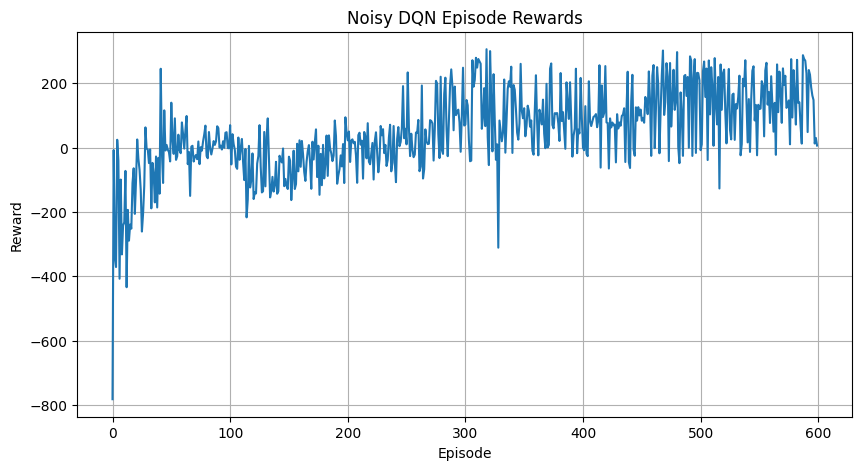

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [9]:
# 학습 곡선
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("Noisy DQN Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("noisy-dqn")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")

<div class="md-recitation">
  Sources
  <ol>
  <li><a href="https://github.com/waleedka/hiddenlayer/issues/96">https://github.com/waleedka/hiddenlayer/issues/96</a></li>
  <li><a href="https://github.com/waleedka/hiddenlayer/issues/96">https://github.com/waleedka/hiddenlayer/issues/96</a></li>
  <li><a href="https://github.com/waleedka/hiddenlayer/issues/96">https://github.com/waleedka/hiddenlayer/issues/96</a></li>
  <li><a href="https://colab.research.google.com/github/Curt-Park/rainbow-is-all-you-need/blob/master/08.rainbow.ipynb">https://colab.research.google.com/github/Curt-Park/rainbow-is-all-you-need/blob/master/08.rainbow.ipynb</a></li>
  <li><a href="https://colab.research.google.com/github/Curt-Park/rainbow-is-all-you-need/blob/master/08.rainbow.ipynb">https://colab.research.google.com/github/Curt-Park/rainbow-is-all-you-need/blob/master/08.rainbow.ipynb</a></li>
  </ol>
</div>